<a href="https://colab.research.google.com/github/emilyau1-ui/jpc_hubspot_analysis_final.ipynb/blob/main/JPC_HubSpot_Analysis_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Justin Panzer Consulting HubSpot Contact Analysis

This notebook uses the exported HubSpot contact dataset to identify useful business patterns for Justin Panzer Consulting.

The goal is to use the existing HubSpot data to answer practical questions:

- Which contacts are closest to becoming clients?
- What activity patterns are connected to customer conversion?
- Where are contacts getting stuck in the pipeline?
- Which contacts may be worth prioritizing for follow-up?

**Important note:** I really dont know what to find, so this will be a random amount of analysis hoping to find something that can help our presentation for JPC.

## 1. Import libraries and load the data



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


file_path = "hubspot-crm-exports-all-contacts-2026-04-10.csv"

df = pd.read_csv(file_path)


df.shape

(337, 308)

In [ ]:

df.columns[:40]

Index(['Record ID', 'First Name', 'Last Name', 'Annual Revenue',
       'Average Pageviews', 'Budget', 'Buying Role',
       'Campaign of last booking in meetings tool', 'Chat Assistant IQL Date',
       'Chat Assistant Source', 'Chat Assistant:Summary', 'City', 'Close Date',
       'Company Name', 'Company size', 'Contact owner', 'Contact Type',
       'Contact unworked', 'Country/Region', 'Country/Region Code',
       'Create Date', 'Created by user ID', 'Currently in Sequence',
       'Date entered "Customer (Lifecycle Stage Pipeline)"',
       'Date entered "Evangelist (Lifecycle Stage Pipeline)"',
       'Date entered "Lead (Lifecycle Stage Pipeline)"',
       'Date entered "Marketing Qualified Lead (Lifecycle Stage Pipeline)"',
       'Date entered "Opportunity (Lifecycle Stage Pipeline)"',
       'Date entered "Other (Lifecycle Stage Pipeline)"',
       'Date entered "Sales Qualified Lead (Lifecycle Stage Pipeline)"',
       'Date entered "Subscriber (Lifecycle Stage Pipeline)"'

## 2. Select the columns needed for this analysis

The full dataset has many fields. For this project, we only need the columns related to lifecycle stage, lead status, sales activity, contact activity, deals, and closing time.

In [ ]:
# These are the main columns used in the analysis
needed_columns = [
    "Record ID",
    "Company Name",
    "Contact Type",
    "Lifecycle Stage",
    "Lead Status",
    "Create Date",
    "Last Activity Date",
    "Last Contacted",
    "First Deal Created Date",
    "Close Date",
    "Days To Close",
    "Number of Sales Activities",
    "Number of times contacted",
    "Number of Associated Deals",
    "Marketing emails opened",
    "Marketing emails clicked",
    "Marketing emails replied",
    "Original Traffic Source",
    "Latest Traffic Source",
    'Date entered "Lead (Lifecycle Stage Pipeline)"',
    'Date entered "Marketing Qualified Lead (Lifecycle Stage Pipeline)"',
    'Date entered "Sales Qualified Lead (Lifecycle Stage Pipeline)"',
    'Date entered "Opportunity (Lifecycle Stage Pipeline)"',
    'Date entered "Customer (Lifecycle Stage Pipeline)"'
]

needed_columns = [column for column in needed_columns if column in df.columns]

jpc = df[needed_columns].copy()

jpc.head()

,Record ID,Company Name,Contact Type,Lifecycle Stage,Lead Status,Create Date,Last Activity Date,Last Contacted,First Deal Created Date,Close Date,...,Marketing emails opened,Marketing emails clicked,Marketing emails replied,Original Traffic Source,Latest Traffic Source,"Date entered ""Lead (Lifecycle Stage Pipeline)""","Date entered ""Marketing Qualified Lead (Lifecycle Stage Pipeline)""","Date entered ""Sales Qualified Lead (Lifecycle Stage Pipeline)""","Date entered ""Opportunity (Lifecycle Stage Pipeline)""","Date entered ""Customer (Lifecycle Stage Pipeline)"""
0,207043454748,NaN,NaN,Lead,NaN,2026-03-04 14:39,2026-04-01 09:49,2026-03-30 10:58,NaN,NaN,...,NaN,NaN,NaN,Offline Sources,Offline Sources,2026-03-04 14:39,NaN,NaN,NaN,NaN
1,170757732927,NaN,NaN,Other,NaN,2025-10-31 14:47,2026-04-06 16:19,2026-04-06 16:19,NaN,NaN,...,2.0,NaN,NaN,Offline Sources,Offline Sources,2025-10-31 14:47,NaN,NaN,NaN,NaN
2,153197460081,Firelock,Client or Prospect,Customer,Open Deal,2025-09-05 15:47,2026-04-10 10:00,2026-04-10 10:00,2025-09-13 16:34,2025-11-05 15:39,...,3.0,1.0,NaN,Offline Sources,Offline Sources,2025-09-05 15:47,2025-09-05 16:06,2025-09-13 15:17,2025-09-13 16:34,2025-11-05 15:39
3,192351714698,SmartLogic,Client or Prospect,Lead,New,2026-01-12 10:59,2026-03-30 09:00,2026-03-25 09:36,NaN,NaN,...,NaN,NaN,NaN,Offline Sources,Offline Sources,2026-01-12 10:59,NaN,NaN,NaN,NaN
4,197278107744,NaN,NaN,Lead,NaN,2026-01-28 16:16,2026-02-03 14:30,2026-02-03 14:30,NaN,NaN,...,NaN,NaN,NaN,Offline Sources,Offline Sources,2026-01-28 16:16,NaN,NaN,NaN,NaN


## 3. Clean the data

Time to convert dates into proper datetime values and make sure the number columns are numeric.

In [ ]:
# Convert date columns
date_columns = [
    "Create Date",
    "Last Activity Date",
    "Last Contacted",
    "First Deal Created Date",
    "Close Date",
    'Date entered "Lead (Lifecycle Stage Pipeline)"',
    'Date entered "Marketing Qualified Lead (Lifecycle Stage Pipeline)"',
    'Date entered "Sales Qualified Lead (Lifecycle Stage Pipeline)"',
    'Date entered "Opportunity (Lifecycle Stage Pipeline)"',
    'Date entered "Customer (Lifecycle Stage Pipeline)"'
]

for column in date_columns:
    if column in jpc.columns:
        jpc[column] = pd.to_datetime(jpc[column], errors="coerce")

# Convert number columns
number_columns = [
    "Days To Close",
    "Number of Sales Activities",
    "Number of times contacted",
    "Number of Associated Deals",
    "Marketing emails opened",
    "Marketing emails clicked",
    "Marketing emails replied"
]

for column in number_columns:
    if column in jpc.columns:
        jpc[column] = pd.to_numeric(jpc[column], errors="coerce")
        jpc[column] = jpc[column].fillna(0)

# Create a simple customer flag
jpc["became_customer"] = jpc["Lifecycle Stage"].eq("Customer")

# Also flag anyone who ever entered the customer stage
customer_date_column = 'Date entered "Customer (Lifecycle Stage Pipeline)"'
if customer_date_column in jpc.columns:
    jpc["ever_became_customer"] = jpc[customer_date_column].notna()
else:
    jpc["ever_became_customer"] = jpc["became_customer"]

jpc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337 entries, 0 to 336
Data columns (total 26 columns):
 #   Column                                                              Non-Null Count  Dtype         
---  ------                                                              --------------  -----         
 0   Record ID                                                           337 non-null    int64         
 1   Company Name                                                        216 non-null    object        
 2   Contact Type                                                        191 non-null    object        
 3   Lifecycle Stage                                                     327 non-null    object        
 4   Lead Status                                                         139 non-null    object        
 5   Create Date                                                         337 non-null    datetime64[ns]
 6   Last Activity Date                                        

## 4. Pipeline overview

This section shows how many contacts are currently in each lifecycle stage. This gives a quick overview

In [ ]:
lifecycle_counts = jpc["Lifecycle Stage"].fillna("Missing").value_counts().reset_index()
lifecycle_counts.columns = ["Lifecycle Stage", "Count"]

lifecycle_counts

,Lifecycle Stage,Count
0,Lead,159
1,Sales Qualified Lead,48
2,Marketing Qualified Lead,39
3,Opportunity,29
4,Subscriber,16
5,Other,13
6,Customer,13
7,Evangelist,10
8,Missing,10


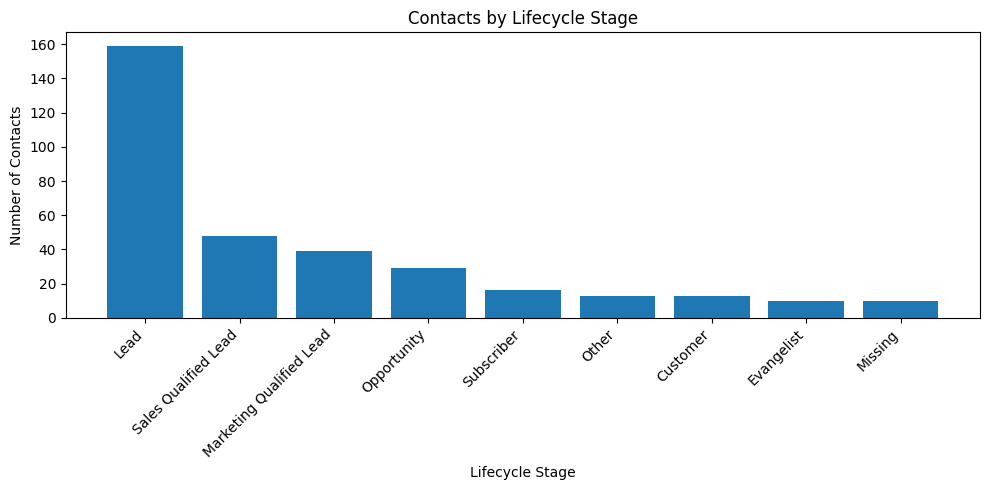

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(lifecycle_counts["Lifecycle Stage"], lifecycle_counts["Count"])
plt.title("Contacts by Lifecycle Stage")
plt.xlabel("Lifecycle Stage")
plt.ylabel("Number of Contacts")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

Most contacts are still in the early parts of the pipeline, especially the Lead stage. This means JPC may not only need more contacts, but also a better way to move qualified contacts forward.

## 5. Conversion funnel

This section counts how many contacts have ever entered each major lifecycle stage. This can be useful if a contact may have moved through different stages over time.

In [ ]:
stage_date_columns = {
    "Lead": 'Date entered "Lead (Lifecycle Stage Pipeline)"',
    "Marketing Qualified Lead": 'Date entered "Marketing Qualified Lead (Lifecycle Stage Pipeline)"',
    "Sales Qualified Lead": 'Date entered "Sales Qualified Lead (Lifecycle Stage Pipeline)"',
    "Opportunity": 'Date entered "Opportunity (Lifecycle Stage Pipeline)"',
    "Customer": 'Date entered "Customer (Lifecycle Stage Pipeline)"'
}

funnel_rows = []

for stage, column in stage_date_columns.items():
    if column in jpc.columns:
        count = jpc[column].notna().sum()
        funnel_rows.append({"Stage Entered": stage, "Contacts": count})

funnel = pd.DataFrame(funnel_rows)
funnel

,Stage Entered,Contacts
0,Lead,317
1,Marketing Qualified Lead,52
2,Sales Qualified Lead,57
3,Opportunity,37
4,Customer,17


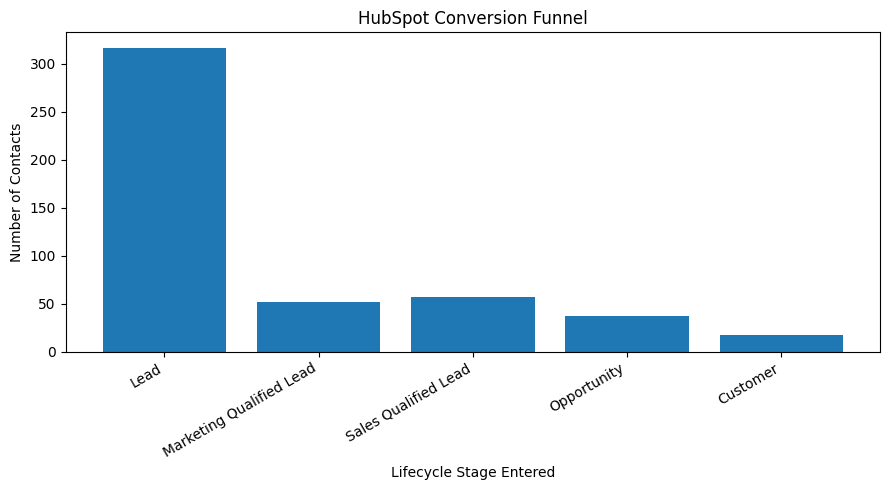

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(funnel["Stage Entered"], funnel["Contacts"])
plt.title("HubSpot Conversion Funnel")
plt.xlabel("Lifecycle Stage Entered")
plt.ylabel("Number of Contacts")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

This funnel helps show where the biggest drop-off happens. If many contacts enter Lead but fewer reach Opportunity or Customer, then JPC may need a clearer follow-up process for qualified leads.

## 6. Sales activity compared to customer conversion

We will compare sales activity against whether a contact became a customer.

In [ ]:
activity_summary = jpc.groupby("ever_became_customer")[[
    "Number of Sales Activities",
    "Number of times contacted",
    "Number of Associated Deals"
]].mean().reset_index()

activity_summary["ever_became_customer"] = activity_summary["ever_became_customer"].replace({
    True: "Became Customer",
    False: "Did Not Become Customer"
})

activity_summary

,ever_became_customer,Number of Sales Activities,Number of times contacted,Number of Associated Deals
0,Did Not Become Customer,9.484375,5.956250,0.071875
1,Became Customer,41.705882,28.823529,1.294118


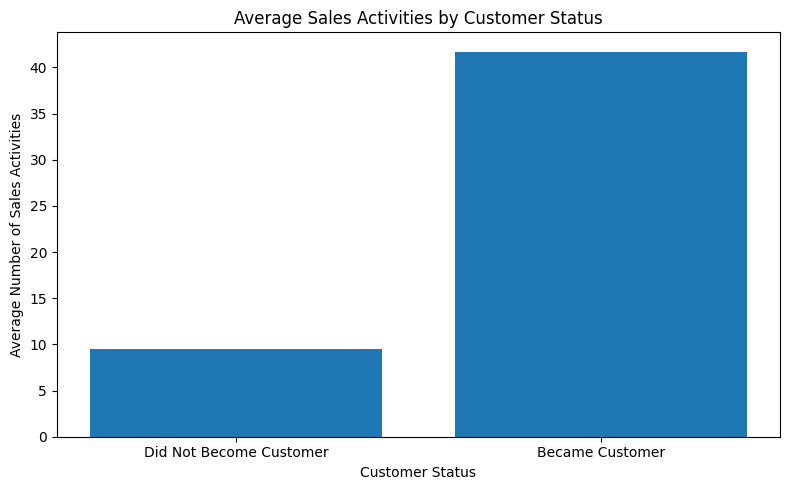

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(activity_summary["ever_became_customer"], activity_summary["Number of Sales Activities"])
plt.title("Average Sales Activities by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Number of Sales Activities")
plt.tight_layout()
plt.show()

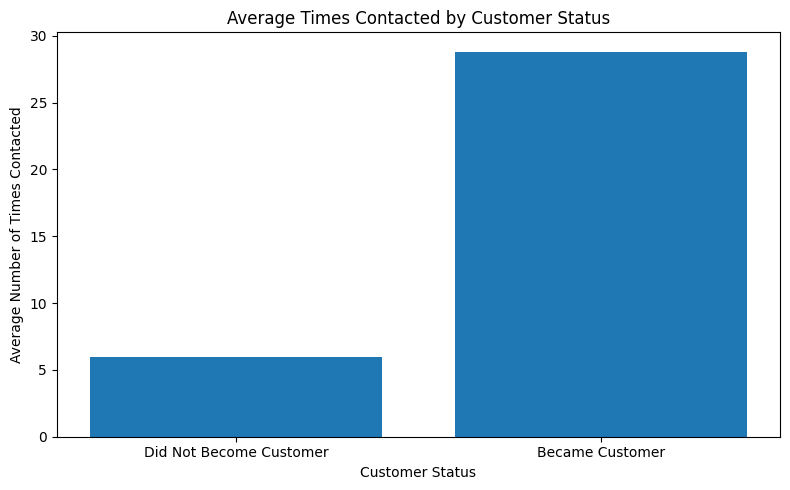

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(activity_summary["ever_became_customer"], activity_summary["Number of times contacted"])
plt.title("Average Times Contacted by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Number of Times Contacted")
plt.tight_layout()
plt.show()

### Interpretation

If customers have higher average sales activity and more contact attempts, this suggests that consistent follow-up may be connected to client conversion. This does not prove that activity alone causes conversion, still a useful insight.

## 7. Activity rate groups

Instead of only looking at averages, we can group contacts by sales activity level and calculate the customer rate in each group.

In [ ]:
# Create sales activity groups
jpc["sales_activity_group"] = pd.cut(
    jpc["Number of Sales Activities"],
    bins=[-1, 0, 5, 15, 50, float("inf")],
    labels=["0", "1-5", "6-15", "16-50", "50+"]
)

activity_conversion = jpc.groupby("sales_activity_group", observed=False).agg(
    contacts=("Record ID", "count"),
    customers=("ever_became_customer", "sum")
).reset_index()

activity_conversion["customer_rate"] = activity_conversion["customers"] / activity_conversion["contacts"]
activity_conversion["customer_rate_percent"] = (activity_conversion["customer_rate"] * 100).round(1)

activity_conversion

,sales_activity_group,contacts,customers,customer_rate,customer_rate_percent
0,0,53,1,0.018868,1.9
1,1-5,121,1,0.008264,0.8
2,6-15,107,4,0.037383,3.7
3,16-50,46,6,0.130435,13.0
4,50+,10,5,0.500000,50.0


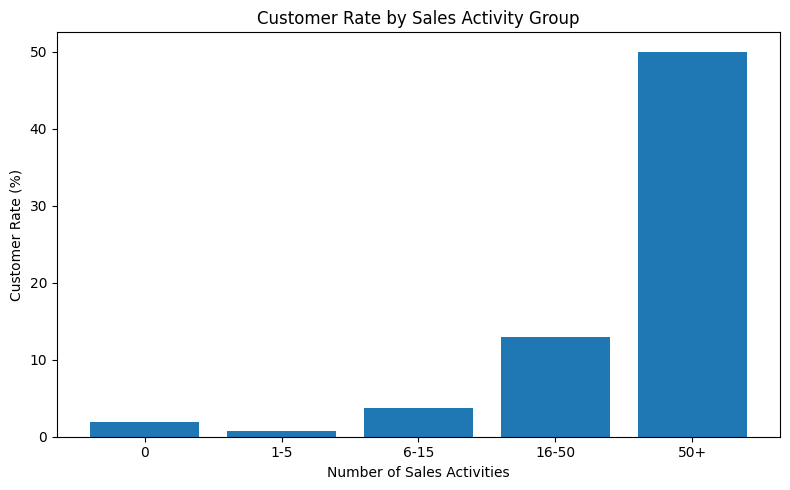

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(activity_conversion["sales_activity_group"].astype(str), activity_conversion["customer_rate_percent"])
plt.title("Customer Rate by Sales Activity Group")
plt.xlabel("Number of Sales Activities")
plt.ylabel("Customer Rate (%)")
plt.tight_layout()
plt.show()

### Interpretation

This chart can help explain whether contacts with more sales activity are more likely to become customers.

## 8. Lead status performance

Lead Status is useful because it tells us where contacts are in the sales process. Here, we calculate how many contacts are in each lead status and what percentage became customers.

In [ ]:
lead_status_summary = jpc.groupby(jpc["Lead Status"].fillna("Missing")).agg(
    contacts=("Record ID", "count"),
    customers=("ever_became_customer", "sum"),
    avg_sales_activities=("Number of Sales Activities", "mean"),
    avg_times_contacted=("Number of times contacted", "mean")
).reset_index()

lead_status_summary["customer_rate_percent"] = (
    lead_status_summary["customers"] / lead_status_summary["contacts"] * 100
).round(1)

lead_status_summary = lead_status_summary.sort_values("customer_rate_percent", ascending=False)
lead_status_summary

,Lead Status,contacts,customers,avg_sales_activities,avg_times_contacted,customer_rate_percent
1,Bad Timing,1,1,40.000000,25.000000,100.0
2,Connected,7,5,30.714286,20.857143,71.4
7,Open Deal,10,5,54.700000,38.000000,50.0
0,Attempted to Contact,17,1,8.235294,3.882353,5.9
3,In Progress,18,1,12.333333,6.000000,5.6
6,Open,57,1,6.228070,2.649123,1.8
4,Missing,198,3,10.136364,7.161616,1.5
5,New,25,0,7.240000,3.400000,0.0
8,Unqualified,4,0,9.250000,4.250000,0.0


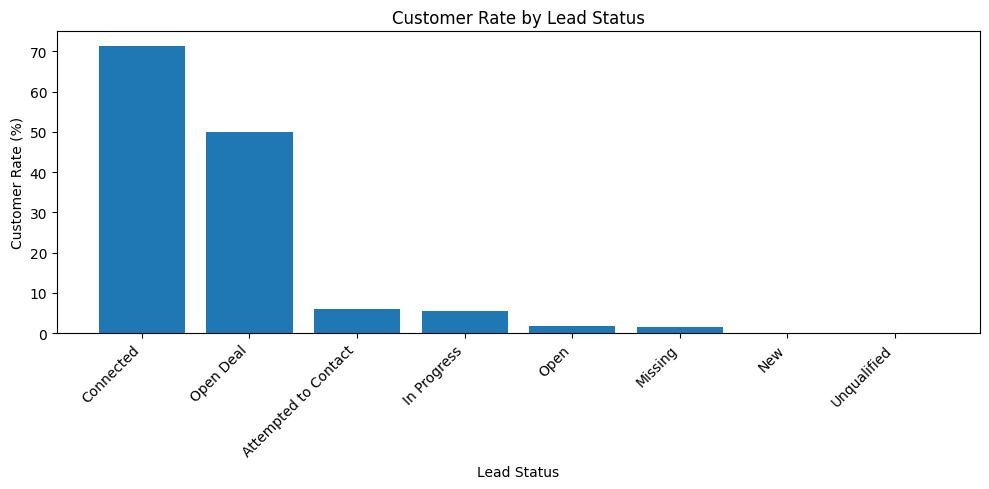

In [ ]:
top_lead_statuses = lead_status_summary[lead_status_summary["contacts"] >= 3].copy()

plt.figure(figsize=(10, 5))
plt.bar(top_lead_statuses["Lead Status"], top_lead_statuses["customer_rate_percent"])
plt.title("Customer Rate by Lead Status")
plt.xlabel("Lead Status")
plt.ylabel("Customer Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

Lead statuses with higher customer rates can help JPC decide where to focus attention first. For example, contacts marked as connected, open deal, opportunity, or sales qualified may deserve higher follow-up priority than completely new or untouched leads.

## 9. Time to close

The Days To Close column helps estimate how long it usually takes a contact to become a customer after entering the pipeline.

In [ ]:
closed_contacts = jpc[jpc["Days To Close"] > 0].copy()

time_to_close_summary = closed_contacts["Days To Close"].describe()
time_to_close_summary

,Days To Close
count,17.000000
mean,33.588235
std,32.052806
min,1.000000
25%,1.000000
50%,21.000000
75%,61.000000
max,90.000000


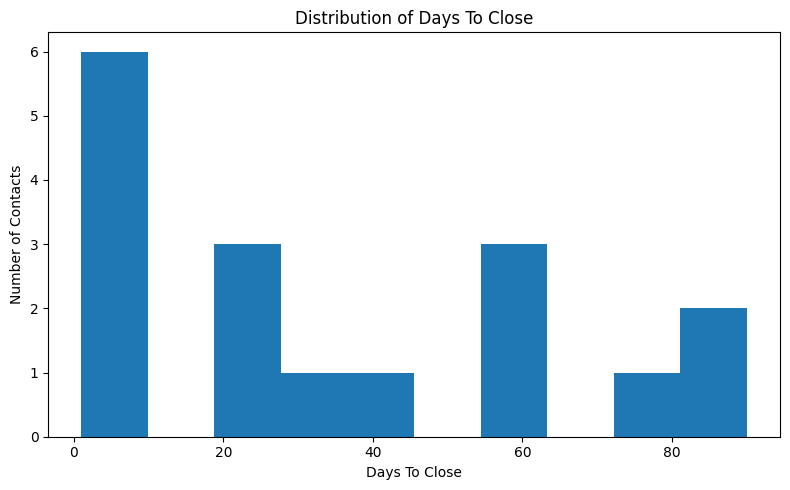

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(closed_contacts["Days To Close"], bins=10)
plt.title("Distribution of Days To Close")
plt.xlabel("Days To Close")
plt.ylabel("Number of Contacts")
plt.tight_layout()
plt.show()

### Interpretation

This can help JPC understand the normal closing window. If most closed contacts convert within a few weeks, then contacts that have been inactive for much longer may need a different follow-up strategy.

## 10. Recent activity and inactive contacts

This section looks at how recently contacts had activity in HubSpot. This can help create a practical re-engagement list.

In [ ]:
# The export date is part of the file name, so we will use that as the reference date
export_date = pd.to_datetime("2026-04-10")

jpc["days_since_last_activity"] = (export_date - jpc["Last Activity Date"]).dt.days

activity_recency = pd.DataFrame({
    "Activity Window": ["Within 30 days", "Within 60 days", "Within 90 days", "Within 180 days", "No last activity date"],
    "Contacts": [
        (jpc["days_since_last_activity"] <= 30).sum(),
        (jpc["days_since_last_activity"] <= 60).sum(),
        (jpc["days_since_last_activity"] <= 90).sum(),
        (jpc["days_since_last_activity"] <= 180).sum(),
        jpc["Last Activity Date"].isna().sum()
    ]
})

activity_recency

,Activity Window,Contacts
0,Within 30 days,53
1,Within 60 days,70
2,Within 90 days,92
3,Within 180 days,194
4,No last activity date,53


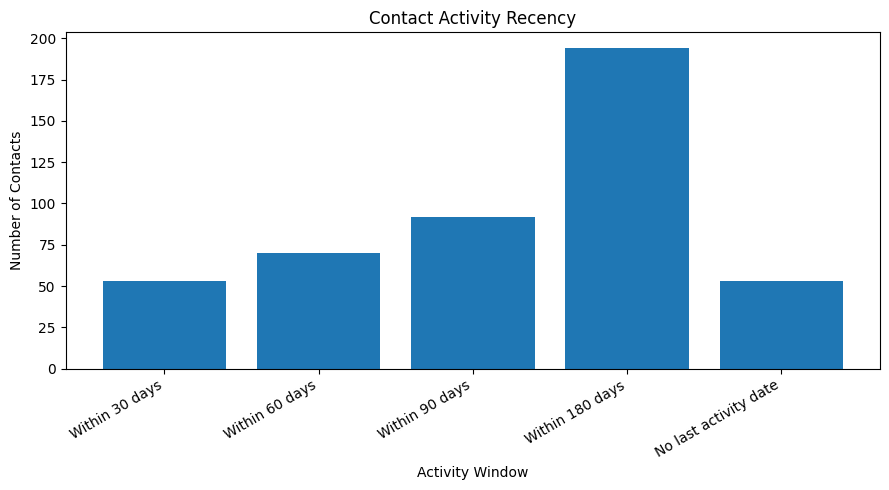

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(activity_recency["Activity Window"], activity_recency["Contacts"])
plt.title("Contact Activity Recency")
plt.xlabel("Activity Window")
plt.ylabel("Number of Contacts")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

##11. Probability Analysis

In [ ]:
df["is_customer"] = df["Lifecycle Stage"].astype(str).str.lower().eq("customer")

lead_status_probability = (
    df.groupby("Lead Status")
    .agg(
        total_contacts=("is_customer", "count"),
        customers=("is_customer", "sum"),
        probability_customer=("is_customer", "mean")
    )
    .sort_values("probability_customer", ascending=False)
)

lead_status_probability

,total_contacts,customers,probability_customer
Lead Status,,,
Connected,7,5,0.714286
Open Deal,10,3,0.300000
Attempted to Contact,17,1,0.058824
Open,57,1,0.017544
In Progress,18,0,0.000000
Bad Timing,1,0,0.000000
New,25,0,0.000000
Unqualified,4,0,0.000000


## intepretation

Question: Which lead statuses have the highest probability of becoming customers?

Contacts marked as “Connected” or “Open Deal” have a much higher probability of becoming customers than contacts marked as “New” or “Open.”

In [ ]:
# Probability by sales activity level
df["sales_activity_group"] = pd.cut(
    df["Number of Sales Activities"],
    bins=[-1, 0, 5, 15, 50, float("inf")],
    labels=["0", "1-5", "6-15", "16-50", "50+"]
)

activity_probability = (
    df.groupby("sales_activity_group")
    .agg(
        total_contacts=("is_customer", "count"),
        customers=("is_customer", "sum"),
        probability_customer=("is_customer", "mean")
    )
)

activity_probability

/tmp/ipykernel_1865/3182238178.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sales_activity_group")


,total_contacts,customers,probability_customer
sales_activity_group,,,
0,53,1,0.018868
1-5,121,1,0.008264
6-15,107,3,0.028037
16-50,46,4,0.086957
50+,10,4,0.400000


In [ ]:
# Probability by number of times contacted
df["contacted_group"] = pd.cut(
    df["Number of times contacted"],
    bins=[-1, 0, 5, 15, 50, float("inf")],
    labels=["0", "1-5", "6-15", "16-50", "50+"]
)

contact_probability = (
    df.groupby("contacted_group")
    .agg(
        total_contacts=("is_customer", "count"),
        customers=("is_customer", "sum"),
        probability_customer=("is_customer", "mean")
    )
)

contact_probability

/tmp/ipykernel_1865/3650187968.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("contacted_group")


,total_contacts,customers,probability_customer
contacted_group,,,
0,7,0,0.000000
1-5,183,1,0.005464
6-15,58,4,0.068966
16-50,23,3,0.130435
50+,8,4,0.500000


In [ ]:
# Conditional probability comparison
prob_high_activity = df.loc[
    df["Number of Sales Activities"] > 15, "is_customer"
].mean()

prob_low_activity = df.loc[
    df["Number of Sales Activities"] <= 15, "is_customer"
].mean()

print(f"P(Customer | more than 15 sales activities): {prob_high_activity:.2%}")
print(f"P(Customer | 15 or fewer sales activities): {prob_low_activity:.2%}")

P(Customer | more than 15 sales activities): 14.29%
P(Customer | 15 or fewer sales activities): 1.78%


We added a probability analysis to estimate how likely contacts are to become customers based on their HubSpot status and activity levels. The goal was not to predict contracts perfectly, but to identify useful patterns in the existing CRM data. The analysis showed that customer probability was higher among contacts with more sales activity, more contact attempts, and stronger lead statuses such as Connected or Open Deal. This suggests JPC may benefit from prioritizing contacts who already show signs of movement through the sales pipeline.

## 12. Final takeaways



Possible findings we can present:

1. Most contacts are still in early lifecycle stages, especially Lead.
2. Contacts with more sales activities and contact attempts showed stronger conversion trends.
3. Certain lead statuses, such as Connected or Open Deal, may be stronger signals of conversion.
4. Time-to-close helps estimate how long the follow-up process usually takes.
5. A simple priority score can turn HubSpot data into an actionable follow-up list.

Recommendation

> Since JPC already has existing assets and does not need a new design system, our team focused on using the existing HubSpot data to support client growth. The analysis explored engagement and activity patterns that may help identify higher-priority contacts for follow-up and outreach. While the dataset was limited, the project demonstrates how HubSpot data can be organized and analyzed to support future client acquisition and retention efforts without requiring a new analytics system.


## Limitations

The HubSpot dataset contained a limited number of converted customers, which reduced the reliability of predictive analysis and probability estimates. Some contact records had inconsistent or incomplete engagement history, limiting deeper analysis such as customer lifespan tracking or time-series trends. Because of the dataset size and structure, the findings should be viewed as exploratory and directional rather than definitive business conclusions.